## LLM Usage
I have used LLMs in order to ask questions, have a better understanding, getting access to relevant documentation in order to solve the assignment and to get improvement ideas for the code.
### Personal details
Full Name: Jarl Dang <br>
Civic Number: 20010827-9191






## Dependencies
In order to run the applicaion you will need to install certain libraries

> pip install numpy matplotlib scipy tensorflow

## Import the required libraries

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

## Task 1: Read and visualize the time series data

In order to read the data we simply load it using np.loadtxt. Then to visualise it we simply plot the data with plt. 

In [11]:
training_data = np.loadtxt("A1_training.txt")
validation_data = np.loadtxt("A1_validation.txt")
test_data = np.loadtxt("A1_test.txt")

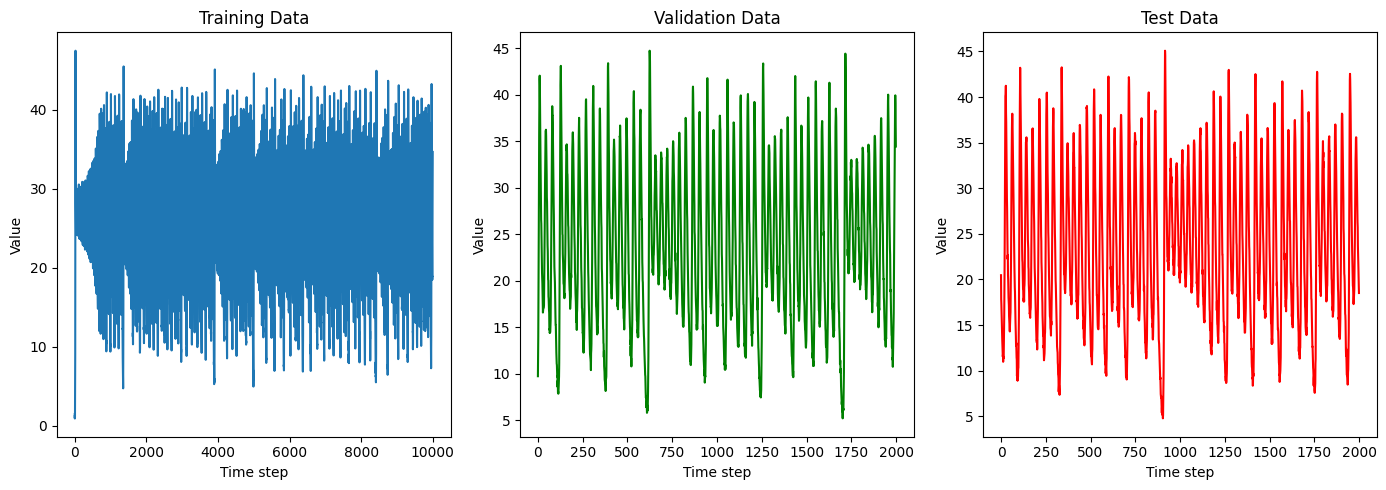

In [12]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 3, 1)
plt.plot(training_data)
plt.title("Training Data")
plt.xlabel("Time step")
plt.ylabel("Value")

plt.subplot(1, 3, 2)
plt.plot(validation_data, color="green")
plt.title("Validation Data")
plt.xlabel("Time step")
plt.ylabel("Value")

plt.subplot(1, 3, 3)
plt.plot(test_data, color="red")
plt.title("Test Data")
plt.xlabel("Time step")
plt.ylabel("Value")

plt.tight_layout()
plt.savefig("task1_time_series.png")
plt.show()

## Arma model
We then create a function in order to define the arma model. This follows directly from the definition of an arma model. The ARMA model is created by combining the AR part and the MA part. In order for the fitting to stay unbiased we set the inital steps to mu, the standard mean value. This will later be used in order to calculate the loss function.

In [13]:
def arma_model(phi, theta, mu, data):
    """
    General ARMA(p, q) model.
    Returns predictions (y_hat) and residuals (eps).
    """
    p = len(phi)
    q = len(theta)
    n = len(data)
    eps = np.zeros(n)
    y_hat = np.zeros(n)

    for t in range(max(p, q)):
        y_hat[t] = mu
        eps[t] = data[t] - y_hat[t]

    for t in range(max(p, q), n):
        ar_part = 0.0
        for i in range(p):
            ar_part = ar_part + phi[i] * data[t - i - 1]

        ma_part = 0.0
        for j in range(q):
            ma_part = ma_part + theta[j] * eps[t - j - 1]

        y_hat[t] = mu + ar_part + ma_part
        eps[t] = data[t] - y_hat[t]

    return y_hat, eps

## Loss function
After creating the ARMA model we need a function to calculate the loss in order to fit the model. This loss function is calculated according to theory and is taken as the negative log-likelihood for a Gaussian error model, which is the standard loss function for ARMA models.

In [14]:


def arma_loss(params, data, p, q, mu, sigma):
    """
    Negative log-likelihood loss for ARMA(p, q).
    params: [phi_1, ..., phi_p, theta_1, ..., theta_q]
    """
    phi = params[:p]
    theta = params[p : p + q]

    y_hat, eps = arma_model(phi, theta, mu, data)

    n = len(data)
    loss = 0.0
    for t in range(n):
        loss = loss + np.log(sigma) + (eps[t] ** 2) / (2 * sigma**2)
    return loss

## Prediction Function
We then need to create a function in order to actually predict one step ahead. This function is exactly the same as the arma model, but we change the values for the inital predictions. Instead of using the mean we use the real data, and instead of using the residuals we set it to zero since the true errors are unknown at prediction time.

In [15]:
def arma_predict_one_step(phi, theta, mu, data):
    """
    One-step-ahead prediction on data using fitted ARMA parameters.
    For each t, predict X_t using actual past values and past residuals.
    """
    p = len(phi)
    q = len(theta)
    n = len(data)
    eps = np.zeros(n)
    y_hat = np.zeros(n)

    for t in range(max(p, q)):
        y_hat[t] = data[t]
        eps[t] = 0

    for t in range(max(p, q), n):
        ar_part = 0.0
        for i in range(p):
            ar_part = ar_part + phi[i] * data[t - i - 1]

        ma_part = 0.0
        for j in range(q):
            ma_part = ma_part + theta[j] * eps[t - j - 1]

        y_hat[t] = mu + ar_part + ma_part
        eps[t] = data[t] - y_hat[t]

    return y_hat

# Task 2

## Fitting the ARMA model
Now we run the training in order to actually fit the arma model. We use the minimize function in order to minimize the loss function with p and q as variables using the Nelder-Mead method. This allows us to find the best values of Phi and Theta which minimizes the loss function.

In order to find the best parameters of P and Q we do a gridsearch, meaning we do two for loops in order to try every combination where P and Q can take values from 1 to 4.

In the end we print the best configuration that yielded the lowest RMSE
> The best configuration found by the program was ARMA(2,4) and yielded the following results:
> <br> Best (p, q): (2, 4) 
> <br> RMSE: 1.7700185565719335
> <br> Best phi: [-0.08567026  0.19421197]
> <br> Best theta: [1.37749712 1.35641255 1.00323093 0.43720808]


In [16]:

best_rmse = float("inf")
best_p = None
best_q = None
best_phi = None
best_theta = None
best_pred = None

mu = np.mean(training_data)
sigma = np.std(training_data)

for p in range(1, 5):
    for q in range(1, 5):
        init_params = np.zeros(p + q)
        try:
            result = minimize(
                arma_loss,
                init_params,
                args=(training_data, p, q, mu, sigma),
                method="Nelder-Mead",
                tol=1e-4,
            )
            phi = result.x[:p]
            theta = result.x[p : p + q]
            pred = arma_predict_one_step(phi, theta, mu, validation_data)
            rmse = np.sqrt(np.mean((validation_data - pred) ** 2))
            print(f"p={p}, q={q}, RMSE={rmse}")
            if rmse < best_rmse:
                best_rmse = rmse
                best_p = p
                best_q = q
                best_phi = phi
                best_theta = theta
                best_pred = pred
        except Exception as e:
            print(f"Failed for p={p}, q={q}: {e}")

print(f"\nBest (p, q): ({best_p}, {best_q}) with RMSE: {best_rmse}")
print("Best phi:", best_phi)
print("Best theta:", best_theta)

C:\Users\Jenny\AppData\Local\Temp\ipykernel_15496\1286334798.py:23: RuntimeWarning: overflow encountered in scalar multiply
  ma_part = ma_part + theta[j] * eps[t - j - 1]
C:\Users\Jenny\AppData\Local\Temp\ipykernel_15496\2761994522.py:14: RuntimeWarning: overflow encountered in scalar power
  loss = loss + np.log(sigma) + (eps[t] ** 2) / (2 * sigma**2)


p=1, q=1, RMSE=4.401167575100682
p=1, q=2, RMSE=2.8216080066881197


C:\Users\Jenny\AppData\Local\Temp\ipykernel_15496\1286334798.py:23: RuntimeWarning: invalid value encountered in scalar add
  ma_part = ma_part + theta[j] * eps[t - j - 1]


p=1, q=3, RMSE=2.117067332597713
p=1, q=4, RMSE=1.7938582016906413
p=2, q=1, RMSE=4.309667780673055
p=2, q=2, RMSE=2.7058185764813136
p=2, q=3, RMSE=2.1707376452598264
p=2, q=4, RMSE=1.7700185565719335
p=3, q=1, RMSE=3.9660689721881477
p=3, q=2, RMSE=2.8758900307624917
p=3, q=3, RMSE=2.071697494580739
p=3, q=4, RMSE=2.3891449910907205
p=4, q=1, RMSE=3.634552517862601
p=4, q=2, RMSE=2.76029783048302
p=4, q=3, RMSE=2.5687039080670067
p=4, q=4, RMSE=2.383536201978591

Best (p, q): (2, 4) with RMSE: 1.7700185565719335
Best phi: [-0.08567026  0.19421197]
Best theta: [1.37749712 1.35641255 1.00323093 0.43720808]


## Plotting the best result
We run the ARMA prediction with the best configuration gotten above versus the test data. The red represents the predictions made by the ARMA model and the blue is the test data.


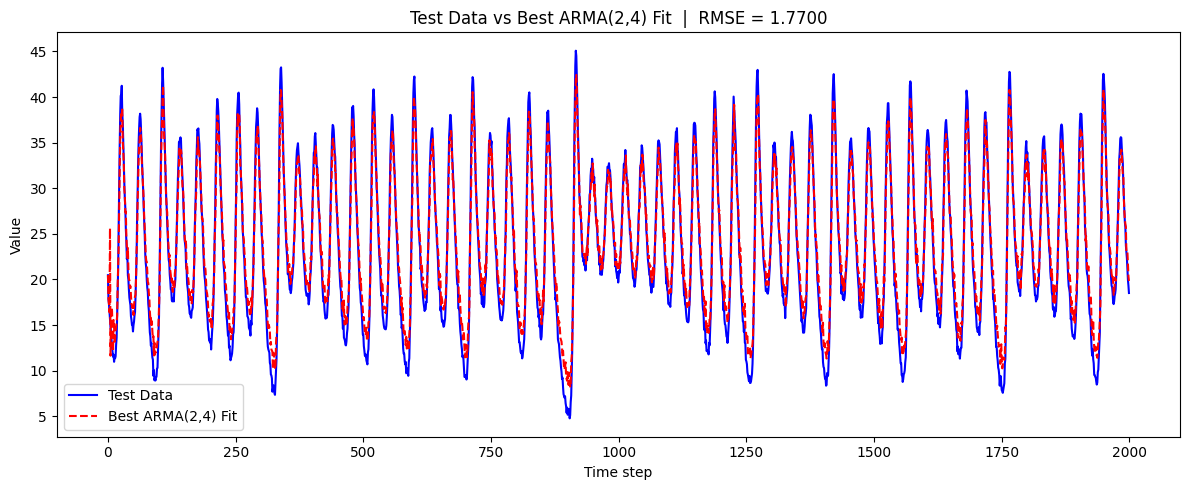

In [ ]:
test_pred = arma_predict_one_step(best_phi, best_theta, mu, test_data)

plt.figure(figsize=(12, 5))
plt.plot(test_data, label="Test Data", color="blue")
plt.plot(
    test_pred, label=f"Best ARMA({best_p},{best_q}) Fit", color="red", linestyle="--"
)
plt.title(f"Test Data vs Best ARMA({best_p},{best_q}) Fit  |  RMSE = {best_rmse:.4f}")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.savefig("task2_arma_best_fit.png")
plt.show()

# Task 3

## Finding suitable P and Q values by doing ACF and PACF
Here we implement the functions needed to calculate the ACF and PACF, the implementations are simply as the formulas are defined. Here I decided that a reasonable amount of lags to calculate is twenty as adviced in lectures.

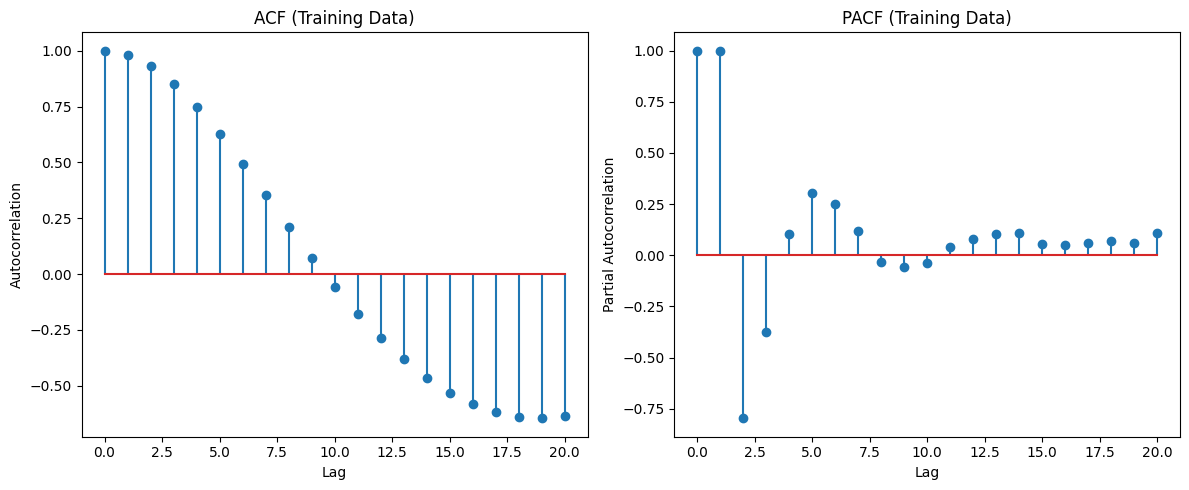

In [19]:


def acf(x, nlags):
    x = list(x)
    n = len(x)
    mean = sum(x) / n
    acf_vals = []
    for k in range(nlags + 1):
        numerator = 0.0
        denominator = 0.0
        for t in range(k, n):
            numerator += (x[t] - mean) * (x[t - k] - mean)
        for t in range(n):
            denominator += (x[t] - mean) ** 2
        acf_vals.append(numerator / denominator)
    return acf_vals


def pacf(x, nlags):
    x = np.array(x)
    pacf_vals = [1.0]
    for k in range(1, nlags + 1):
        X = []
        y = []
        for t in range(k, len(x)):
            X.append([x[t - i - 1] for i in range(k)])
            y.append(x[t])
        X = np.array(X)
        y = np.array(y)
        if len(X) > 0:
            coef = np.linalg.lstsq(X, y, rcond=None)[0]
            pacf_vals.append(coef[-1])
        else:
            pacf_vals.append(0.0)
    return pacf_vals


nlags = 20
acf_vals = acf(training_data, nlags)
pacf_vals = pacf(training_data, nlags)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.stem(range(nlags + 1), acf_vals)
plt.title("ACF (Training Data)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.subplot(1, 2, 2)
plt.stem(range(nlags + 1), pacf_vals)
plt.title("PACF (Training Data)")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.savefig("acf_pacf_training.png")
plt.show()


By analysing these figures we can assume that a q value of around 4 seems reasonable since the magnitude there after seems to decrease. Although it is harder to determine what a good value for p would be since the ACF figure does not clearly indicate a clear cutoff or sharp drop. This suggests that the AR component may not be as dominant or that a lower p value is good enough. It was therefore important that we did the grid search earlier in order to find the best configurations.

# Task 4 

## LSTM
The LSTM implementation is farily straight forward and follows from the documentation written by Tensorflow.

## Imports

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


## Formatting the data

The LSTM network requires the data to be formatted a certain way. It expects an input shape in the form of (samples, timesteps, features). In order to predict the next value we will use a sliding window of size "window_size". This is defined as the number of past values used to predict the next one. It will be set to 10 as adviced on lectures.

In [5]:
training_data = np.loadtxt("A1_training.txt")
validation_data = np.loadtxt("A1_validation.txt")
test_data = np.loadtxt("A1_test.txt")



def create_sequences(data, window_size):
    X = []
    y = []
    for t in range(window_size, len(data)):
        X.append(data[t - window_size : t])
        y.append(data[t])
    X = np.array(X)
    y = np.array(y)
    X = X.reshape(X.shape[0], X.shape[1], 1)
    return X, y


window_size = 10

X_train, y_train = create_sequences(training_data, window_size)
X_val, y_val = create_sequences(validation_data, window_size)
X_test, y_test = create_sequences(test_data, window_size)


## Building and training
In this step we build and train the LSTM model. We save the best model based on the validation loss and we also stop the training early if we stop seeing improvements for 10 generations in a row.

For the optimisation we use the Adam method with the mean squared error for loss calculation.

In [3]:

def build_and_train(num_units, window_size, X_train, y_train, X_val, y_val):
    model = Sequential()
    model.add(LSTM(num_units, activation="tanh", input_shape=(window_size, 1)))
    model.add(Dense(1))

    model.compile(optimizer=Adam(), loss="mse")

    checkpoint = ModelCheckpoint(
        f"best_lstm_{num_units}.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=0,
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=64,
        validation_data=(X_val, y_val),
        callbacks=[checkpoint, early_stop],
        verbose=1,
    )

    return model, history

## Finding the best configuration
In order to find the best amount of LSTM units we simply try several options and pick the one with the lowest validation error. 
> The best result was with 16 LSTM units with an rmse of 5053

In [6]:

unit_options = [8, 16, 32, 64]


best_val_rmse = float("inf")
best_units = None
best_model = None
best_pred = None

for num_units in unit_options:
    print(f"\n--- Training LSTM with {num_units} units ---")
    model, history = build_and_train(
        num_units, window_size, X_train, y_train, X_val, y_val
    )

    # Predict on validation set
    val_pred = model.predict(X_val).flatten()
    val_rmse = np.sqrt(np.mean((y_val - val_pred) ** 2))
    print(f"LSTM ({num_units} units) - Validation RMSE: {val_rmse:.4f}")

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_units = num_units
        best_model = model

# After selecting the best model, evaluate on test set
best_pred = best_model.predict(X_test).flatten()
test_rmse = np.sqrt(np.mean((y_test - best_pred) ** 2))
print(
    f"\nBest LSTM: {best_units} units with Validation RMSE: {best_val_rmse:.4f} and Test RMSE: {test_rmse:.4f}"
)


--- Training LSTM with 8 units ---
Epoch 1/100


c:\Users\jarld\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 544.3176 - val_loss: 484.4592
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 461.8334 - val_loss: 409.4293
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 387.8537 - val_loss: 361.0888
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 340.0954 - val_loss: 320.5945
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 304.0323 - val_loss: 287.8781
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 273.5085 - val_loss: 259.4192
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 246.7262 - val_loss: 234.2277
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 222.7784 - val_loss: 211.5514
Epoch 9/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 201.2130 - val_loss: 191.1195
Epoch 10/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 181.8470 - val_loss: 172.7563
Epoch 11/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 164.3650 - val_loss: 156.1904
Epoch 12/

## Plotting the data
A similar plot as the one done with the ARMA model is now done but with the LSTM model instead in order to compare the results cleanly.

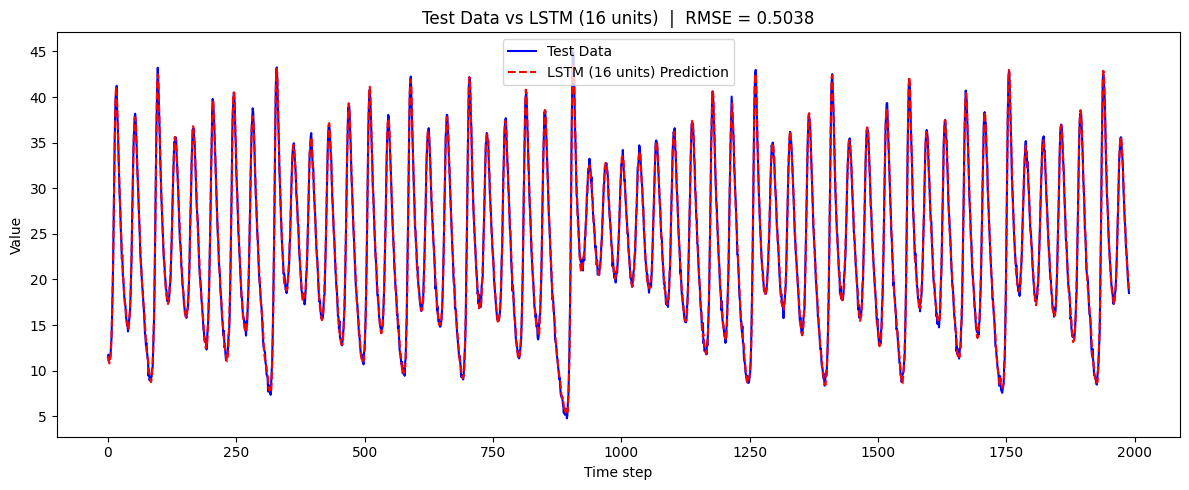

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label="Test Data", color="blue")
plt.plot(
    best_pred,
    label=f"LSTM ({best_units} units) Prediction",
    color="red",
    linestyle="--",
)
plt.title(f"Test Data vs LSTM ({best_units} units)  |  RMSE = {best_val_rmse:.4f}")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.savefig("task_lstm_prediction.png")
plt.show()


# Task 5 Analysing ARMA(2,4)

### Analysing AR
By analysing the p value we can conclude that the 2 most recent timesteps are heavily correlated to the timestep which we are trying to predict. We can also note exactly how strong their influence is by analysing the coefficents(phi) for them. Given the following phi values for the best model:

> <br> Best phi: [-0.08567026  0.19421197]

This indicates that the most recent value (lag 1) has a small negative correlation with the next value, while the second most recent value (lag 2) has a larger positive correlation and plays a more significant role in the prediction.

### Analysing MA
We can analyse the MA in the same way. By studying the q value we can conclude that the 4 most recent timesteps are relevant in order to predict the next, since the q values was 4. We can now analyse the PACF graph to see how these timesteps are correlated to the prediction, but more exactly we can inspect the coefficent values since we have calculate those.

> <br> Best theta: [1.37749712 1.35641255 1.00323093 0.43720808]

This tells us that all of the four past timesteps are positvely correlated in order to predict the next, it also tells us that the most recent timestep impacts the most with their magnitude decreasing as the number of lags increase.


<br>
Putting both of these components together we get the final ARMA equation which we use to predict the next value. This is completely interpretable and tells us exactly what terms are important and how they impact the end result.


$$
\begin{align*}
X_t =\ & \mu \\
      & - 0.0857 \cdot X_{t-1} \\
      & + 0.1942 \cdot X_{t-2} \\
      & + 1.3775 \cdot \epsilon_{t-1} \\
      & + 1.3564 \cdot \epsilon_{t-2} \\
      & + 1.0032 \cdot \epsilon_{t-3} \\
      & + 0.4372 \cdot \epsilon_{t-4}
\end{align*}
$$

### Comparing the models

Strictly comparing the RMSE values of the both models we have RMSE: 1.770 for the ARMA(2,4) model and RMSE:0.5038 for the LSTM version. This is quite a significant performance difference and is definitely worth taking into consideration when choosing a model, although the price in interpretability is steep.

The ARMA model is highly transparent and easy to interpret. It clearly shows the relationship between different time steps and allows us to see exactly how each previous value and residual contributes to the prediction. This makes it straightforward to analyze and understand the model’s behavior, which is a significant advantage in many practical applications and high cost scenarios.


On the other hand the LSTM version provides better performance but sacrifices any explainability and transperancy. It also makes it impossible to explain any decisions made by the model and what factors impacted the results, it is therefore more fitted for situations where performance is everything. 